In [ ]:
# ============================================
# CUSTOMER CHURN ANALYSIS
# OBJECTIVE 1
# IDENTIFY KEY DETERMINANTS OF CUSTOMER CHURN
# ============================================

import pandas as pd

import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Regression
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Machine learning utilities
from sklearn.preprocessing import StandardScaler

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
df = pd.read_excel('Customer-Churn-Dataset.xls', engine='xlrd')

In [ ]:
print("Dataset shape:", df.shape)

print("\nFirst 5 observations:")
display(df.head())

print("\nLast 5 observations:")
display(df.tail())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (10000, 13)

First 5 observations:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,Complain,SatisfactionScore,PointEarned,Churn
0,619,Female,42,2,0.00,1,1,1,101348.88,1,2,464,1
1,608,Female,41,1,83807.86,1,0,1,112542.58,1,3,456,0
2,502,Female,42,8,159660.80,3,1,0,113931.57,1,3,377,1
3,699,Female,39,1,0.00,2,0,0,93826.63,0,5,350,0
4,850,Female,43,2,125510.82,1,1,1,79084.10,0,5,425,0



Last 5 observations:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,Complain,SatisfactionScore,PointEarned,Churn
9995,771,Male,39,5,0.00,2,1,0,96270.64,0,1,300,0
9996,516,Male,35,10,57369.61,1,1,1,101699.77,0,5,771,0
9997,709,Female,36,7,0.00,1,0,1,42085.58,1,3,564,1
9998,772,Male,42,3,75075.31,2,1,0,92888.52,1,2,339,1
9999,792,Female,28,4,130142.79,1,1,0,38190.78,0,3,911,0



Column names:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCreditCard', 'IsActiveMember', 'EstimatedSalary', 'Complain', 'SatisfactionScore', 'PointEarned', 'Churn']

Data types:
CreditScore            int64
Gender                object
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCreditCard          int64
IsActiveMember         int64
EstimatedSalary      float64
Complain               int64
SatisfactionScore      int64
PointEarned            int64
Churn                  int64
dtype: object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  object 
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCreditCard      10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Complain           10000 non-null  int64  
 10  SatisfactionScore  10000 non-null  int64  
 11  PointEarned        10000 non-null  int64  
 12  Churn              10000 non-null  int64  
dtypes: float64(2), int64(10), object(1)
memory usage: 1015.8+ KB


In [ ]:
missing = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage
})

display(missing_table)

,Missing_Count,Missing_Percentage
CreditScore,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0
HasCreditCard,0,0.0
IsActiveMember,0,0.0
EstimatedSalary,0,0.0
Complain,0,0.0


In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:

####Categorical variables

print(df["Gender"].value_counts(dropna=False))

Gender
Male      5457
Female    4543
Name: count, dtype: int64


In [ ]:
print(df["Churn"].value_counts(dropna=False))

Churn
0    7962
1    2038
Name: count, dtype: int64


In [ ]:
binary_variables = [
    "HasCreditCard",
    "IsActiveMember",
    "Complain",
    "Churn"
]

for variable in binary_variables:
    print(f"\n{variable}")
    print(df[variable].value_counts(dropna=False))


HasCreditCard
HasCreditCard
1    7055
0    2945
Name: count, dtype: int64

IsActiveMember
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

Complain
Complain
0    7956
1    2044
Name: count, dtype: int64

Churn
Churn
0    7962
1    2038
Name: count, dtype: int64


In [ ]:
###check data quality for numerical variables

numeric_variables = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary",
    "SatisfactionScore",
    "PointEarned"
]

display(df[numeric_variables].describe().T)

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
SatisfactionScore,10000.0,3.013800,1.405919,1.00,2.00,3.000,4.0000,5.00
PointEarned,10000.0,606.515100,225.924839,119.00,410.00,605.000,801.0000,1000.00


In [ ]:
###check if tisina ma impossible values
###this is important for statistical modelling since we will need to do some inference

print("CreditScore range:")
print(df["CreditScore"].min(), df["CreditScore"].max())

print("\nAge range:")
print(df["Age"].min(), df["Age"].max())

print("\nTenure range:")
print(df["Tenure"].min(), df["Tenure"].max())

print("\nNumOfProducts range:")
print(df["NumOfProducts"].min(), df["NumOfProducts"].max())

print("\nSatisfactionScore range:")
print(df["SatisfactionScore"].min(), df["SatisfactionScore"].max())

print("\nPointEarned range:")
print(df["PointEarned"].min(), df["PointEarned"].max())

CreditScore range:
350 850

Age range:
18 92

Tenure range:
0 10

NumOfProducts range:
1 4

SatisfactionScore range:
1 5

PointEarned range:
119 1000


In [ ]:
###let us analyse our target variable
churn_counts = df["Churn"].value_counts().sort_index()

churn_percentages = df["Churn"].value_counts(
    normalize=True
).sort_index() * 100

churn_summary = pd.DataFrame({
    "Count": churn_counts,
    "Percentage": churn_percentages.round(2)
})

display(churn_summary)

,Count,Percentage
Churn,,
0,7962,79.62
1,2038,20.38


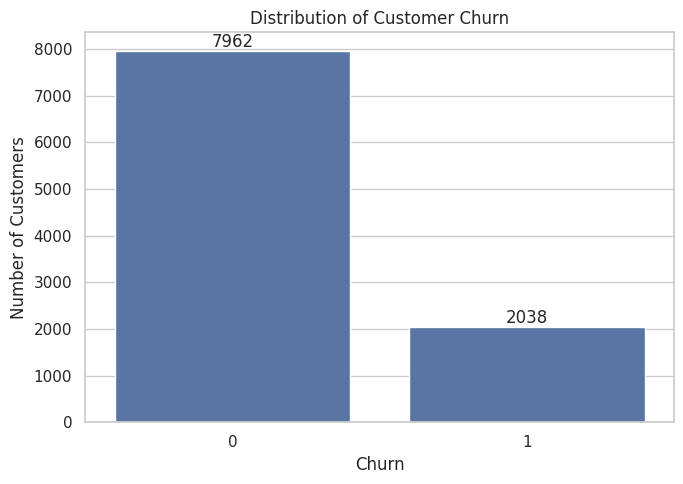

In [ ]:
#####Numerical variables versus churn

##For Objective 1, we determine whether numerical characteristics differ between customers who churned and those who stayed.
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()